In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import constraints
from torch.func import vmap

In [2]:
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, TraceEnum_ELBO, config_enumerate, infer_discrete
from pyro.ops.indexing import Vindex
from pyro import poutine

In [3]:
import numpy as np
import math
from itertools import product, accumulate
import einops
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
import umap  

In [74]:
def generate_distinct_components(K, V, peak_strength=5.0, base_concent=0.1):
    comps = []
    for k in range(K):
        alpha = torch.ones(V) * base_concent
        alpha[k * V // K] = peak_strength
        comp = torch.distributions.Dirichlet(alpha).sample()
        comps.append(comp)
    return torch.stack(comps)  # shape: (K, V)


In [4]:
def generate_distinct_distributions(N, V, concent=0.8):
    dists = []
    alpha = torch.ones(V) * concent  # sparse
    dist = torch.distributions.Dirichlet(alpha)
    samples = dist.sample((N,))
    return samples


In [75]:
def generate_hierarchical_mixture_data(struct_upbd,
    N_per_base=20, M=200, V=100,  # N_per_base: number of samples per base category
    seed=42
):
    # Config
    num_super = struct_upbd["G1"]
    num_base_per_super = struct_upbd["G2"]
    num_features = struct_upbd["G0"]
    samples_per_base = N_per_base
    torch.manual_seed(seed)

    eta=0.2
    word_dists = generate_distinct_components(num_features, V)

    y_means = torch.linspace(-num_features/4, num_features/4, steps=num_features)
    y_stds = 0.1 + 0.1 * torch.rand(num_features)

    alpha_1 = 0.8
    super_prototypes = generate_distinct_distributions(num_super, num_features, alpha_1)

    base_prototypes = []
    alpha_2 = [20]*num_super
    for super_id in range(num_super):
        base_prototypes.append(generate_distinct_distributions(num_base_per_super, num_features, alpha_2[super_id]*super_prototypes[super_id]))
    base_prototypes = torch.stack(base_prototypes)

    X = []
    y = []
    labels_base = []
    labels_super = []
    
    for super_id in range(num_super):
        for base_offset in range(num_base_per_super):
            base_id = super_id*num_base_per_super + base_offset
            base_proto = base_prototypes[super_id][base_offset]
            
            for _ in range(samples_per_base):
                noise = torch.randn(num_features) * 0.1  # local noise around base proto
                doc_dist = base_proto
    
                doc = []
                for word_id in range(M):
                    comp_id = torch.distributions.Categorical(doc_dist).sample().item()
                    word = torch.distributions.Multinomial(1, word_dists[comp_id]).sample()
                    doc.append(word)
                doc = torch.stack(doc)
                
                X.append(doc)
                comp_id = torch.distributions.Categorical(doc_dist).sample().item()
                y.append(torch.normal(mean=y_means[comp_id], std=y_stds[comp_id], size=(1,)))
                labels_base.append(base_id)
                labels_super.append(super_id)
    
    X_data = torch.stack(X)
    y_data = torch.stack(y)
    labels_base = torch.tensor(labels_base)
    labels_super = torch.tensor(labels_super)    

    return {
        "x": X_data,                  # (total_data, M, V)
        "y": y_data,                  # (total_data,)
        "super_labels": labels_super,  # (total_data,)
        "base_labels": labels_base,    # (total_data,)
        "word_dists": word_dists,      # (num_components, V)
        "super_mix_weights": super_prototypes,
        "child_mix_weights": base_prototypes     # (num_super*num_base_per_super, 
        
    }


In [76]:
struct_upbd = {"G0": 6, "G1": 3, "G2": 2}
data = generate_hierarchical_mixture_data(struct_upbd)

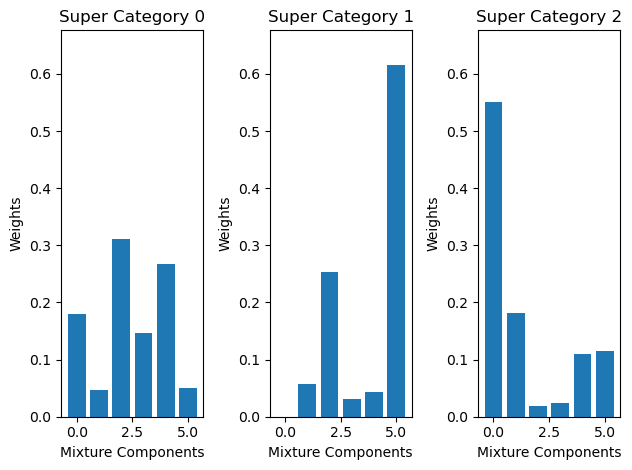

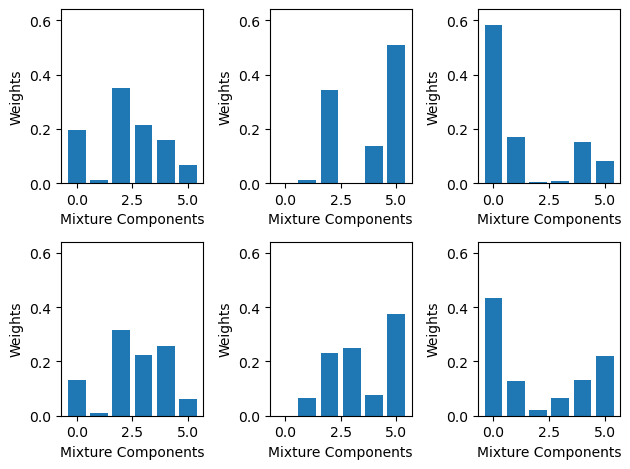

In [77]:
super_mix_weights = data["super_mix_weights"]
child_mix_weights = data["child_mix_weights"]
data = generate_hierarchical_mixture_data(struct_upbd)
fig, axs = plt.subplots(1, struct_upbd["G1"])
for i in range(struct_upbd["G1"]):
    ax = axs[i]
    ax.bar(range(struct_upbd["G0"]), super_mix_weights[i].numpy())
    ax.set_title(f"Super Category {i}")
    ax.set_xlabel("Mixture Components")
    ax.set_ylabel("Weights")
    ax.set_ylim(0, super_mix_weights.max().item() * 1.1)

# fig.suptitle(f"Super Category Weights of {struct_upbd['G0']} Shared Mixture Components", fontsize=16)
fig.tight_layout()
plt.show()

# Bar plots for each component
fig, axs = plt.subplots(struct_upbd["G2"], struct_upbd["G1"])
for i in range(struct_upbd["G2"]):
    for j in range(struct_upbd["G1"]):
        ax = axs[i, j]
        ax.bar(range(struct_upbd["G0"]), child_mix_weights[j][i].numpy())
        # ax.set_title(f"Super Category {j} Child Category {i}")
        ax.set_xlabel("Mixture Components")
        ax.set_ylabel("Weights")
        ax.set_ylim(0, child_mix_weights.max().item() * 1.1)

# fig.suptitle(f"Child Category Weights of {struct_upbd['G1']} Shared Mixture Components", fontsize=16)
fig.tight_layout()
plt.show()

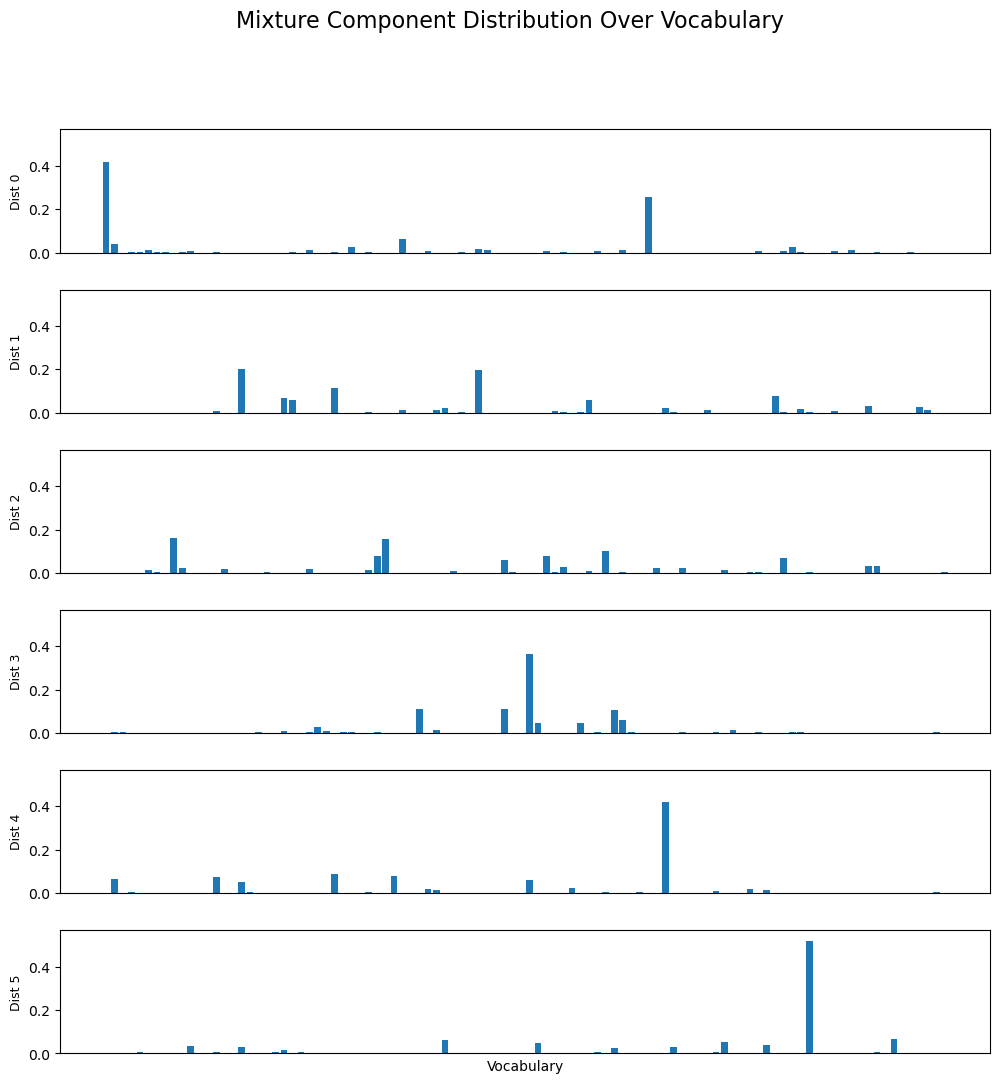

In [78]:
N = struct_upbd["G0"]
V = 100
dists = data["word_dists"]

fig, axs = plt.subplots(N, 1, figsize=(12, 2 * N), sharex=True)  # Share x-axis, increase height

for i in range(N):
    ax = axs[i]
    ax.bar(range(V), dists[i].numpy())
    ax.set_ylabel(f'Dist {i}', fontsize=9)
    ax.set_ylim(0, dists.max().item() * 1.1)

    # Hide x-axis labels except for the last one
    if i < N - 1:
        ax.set_xticks([])
    else:
        ax.set_xlabel("Vocabulary", fontsize=10)

# Tight layout with spacing between plots
fig.suptitle(f"Mixture Component Distribution Over Vocabulary", fontsize=16)
plt.subplots_adjust(hspace=0.3)
plt.show()

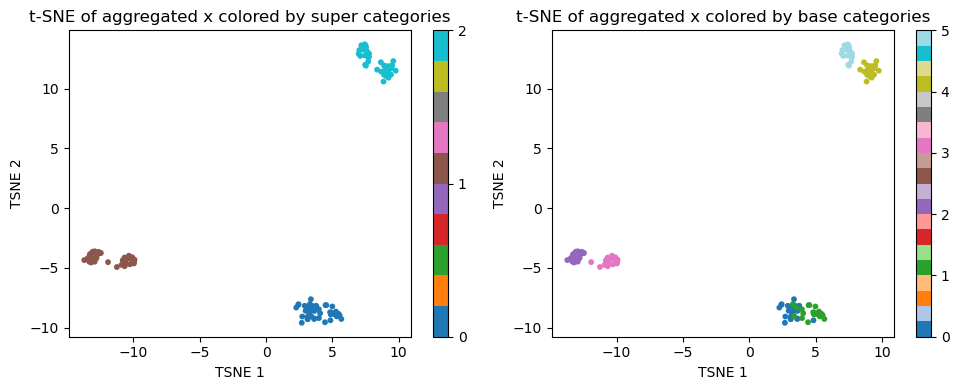

/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


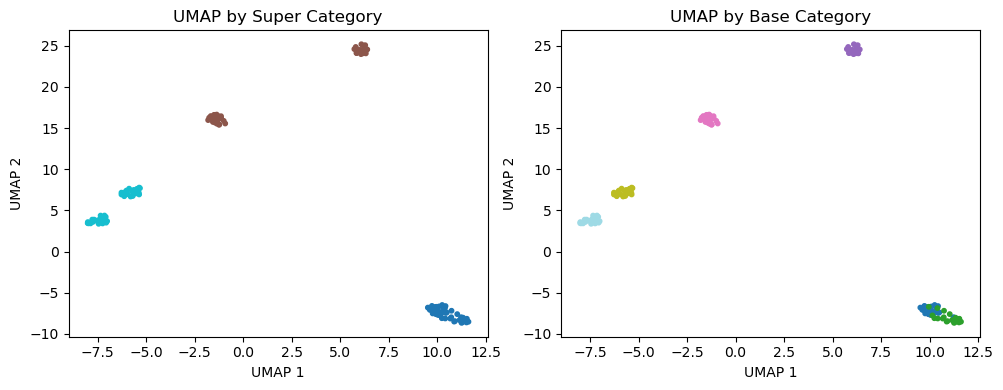

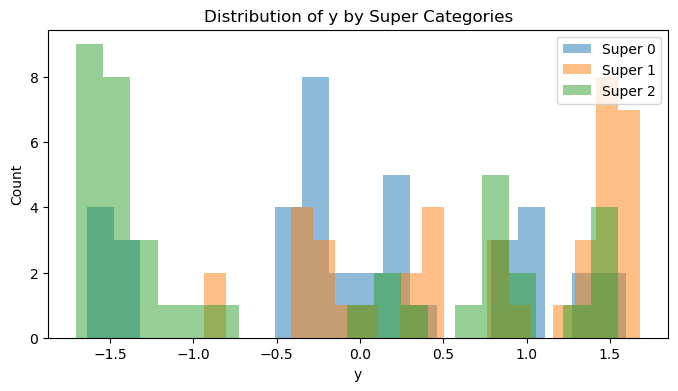

In [79]:
# Run t-SNE
x_agg = data["x"].sum(dim=1)
vocab_size = data["x"].shape[-1]
tsne = TSNE(n_components=2, random_state=0)
x_embedded = tsne.fit_transform(x_agg.numpy())

# Plot t-SNE colored by super categories
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=data["super_labels"], cmap="tab10", s=10)
plt.colorbar(scatter, ticks=range(6))
plt.title("t-SNE of aggregated x colored by super categories")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")

# Plot t-SNE colored by base categories
plt.subplot(1, 2, 2)
scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=data["base_labels"], cmap="tab20", s=10)
plt.colorbar(scatter, ticks=range(18))
plt.title("t-SNE of aggregated x colored by base categories")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")

plt.tight_layout()
plt.show()

# === UMAP projection ===
reducer = umap.UMAP(random_state=0)
x_umap = reducer.fit_transform(x_agg.numpy().astype(np.float32))


# === UMAP Plots ===
plt.figure(figsize=(10, 4))

# Super category coloring
plt.subplot(1, 2, 1)
plt.scatter(x_umap[:, 0], x_umap[:, 1], c=data["super_labels"], cmap="tab10", s=10)
plt.title("UMAP by Super Category")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

# Base category coloring
plt.subplot(1, 2, 2)
plt.scatter(x_umap[:, 0], x_umap[:, 1], c=data["base_labels"], cmap="tab20", s=10)
plt.title("UMAP by Base Category")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.tight_layout()
plt.show()

# Plot distribution of y by super categories
plt.figure(figsize=(8, 4))
for super_id in range(struct_upbd["G1"]):
    y_vals = data["y"][data["super_labels"] == super_id].numpy()
    plt.hist(y_vals, bins=20, alpha=0.5, label=f"Super {super_id}")

plt.title("Distribution of y by Super Categories")
plt.xlabel("y")
plt.ylabel("Count")
plt.legend()
plt.show()



In [102]:
print(data["x"].dtype)
print(data["y"].dtype)

torch.float64
torch.float32


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


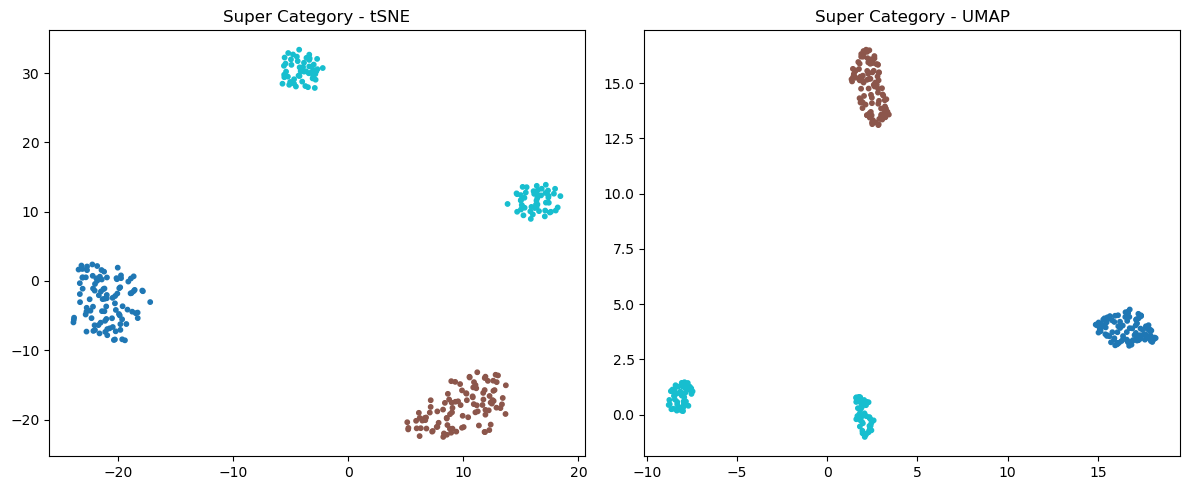

/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


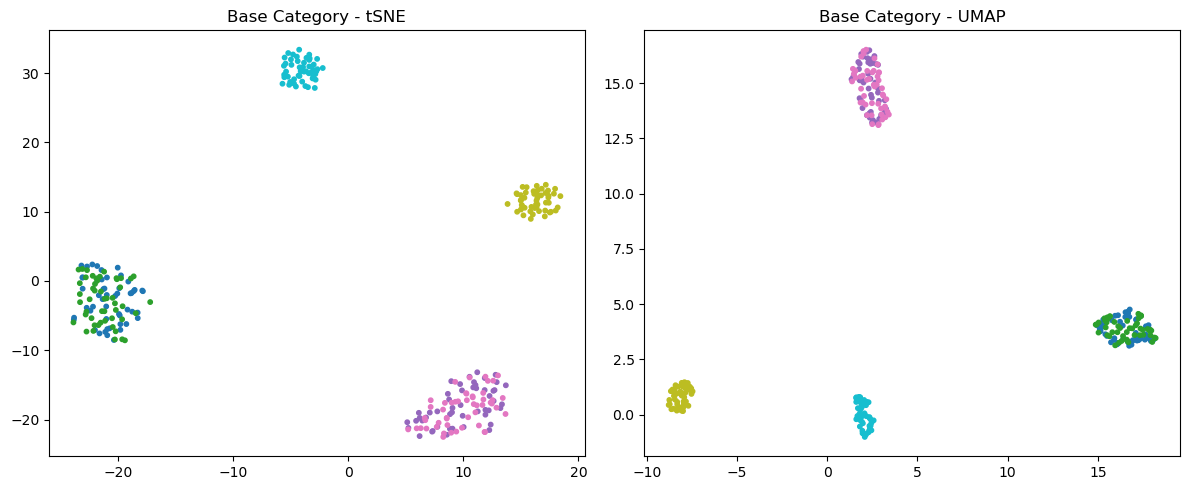

In [76]:
def visualize(X, labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    X_tsne = TSNE(n_components=2, perplexity=30, metric='euclidean', random_state=0).fit_transform(X)
    axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=10)
    axes[0].set_title(f"{title} - tSNE")

    X_umap = umap.UMAP(metric='euclidean', random_state=0).fit_transform(X)
    axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap='tab10', s=10)
    axes[1].set_title(f"{title} - UMAP")

    plt.tight_layout()
    plt.show()

visualize(X, labels_super, "Super Category")
visualize(X, labels_base, "Base Category")
